# DirectNet — experimente complete

Notebook-ul completează partea de cod cerută pentru prezentare:

- replicare DirectNet pe Pavia;
- baseline GRX;
- variația `Win` și `Wout`;
- ROC-AUC și Average Precision (PR-AUC);
- Precision, Recall, F1, FP și FN;
- analiza pragului;
- cazuri concrete de False Positives și False Negatives;
- CSV-uri și grafice salvate automat.

> Este o reimplementare după metodologia articolului, nu codul oficial al autorilor.

În Colab selectează `Runtime → Change runtime type → T4 GPU`.

## 1. Importuri și configurare

In [1]:
import copy
import gc
import random
import time
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.decomposition import PCA
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, RandomSampler

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
torch.backends.cudnn.benchmark = True
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 2. Parametrii experimentelor

La prima rulare păstrează `QUICK_MODE = True`. Pentru rezultatele finale poți seta `False`.

In [2]:
QUICK_MODE = False

if QUICK_MODE:
    MAX_EPOCHS = 35
    TRAIN_SAMPLES_PER_EPOCH = 5000
    VALIDATION_SAMPLES = 1800
    PATIENCE = 7
else:
    MAX_EPOCHS = 80
    TRAIN_SAMPLES_PER_EPOCH = 10000
    VALIDATION_SAMPLES = 2500
    PATIENCE = 12

BATCH_SIZE = 100
INFERENCE_BATCH_SIZE = 256
LEARNING_RATE = 1e-4
NUM_WORKERS = 0
HIDDEN_CHANNELS = 64

WIN_VALUES = [1, 3, 5, 7, 9]
WOUT_VALUES = [15, 19, 23]
REFERENCE_WOUT = 19

OUTPUT_DIR = Path("/content/directnet_experiments")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Quick mode:", QUICK_MODE)
print("Max epochs:", MAX_EPOCHS)
print("Samples/epoch:", TRAIN_SAMPLES_PER_EPOCH)

Quick mode: True
Max epochs: 35
Samples/epoch: 5000


## 3. Descărcarea și încărcarea setului Pavia

In [3]:
DATA_DIR = Path("/content/directnet_data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATA_PATH = DATA_DIR / "pavia.mat"

DATA_URLS = [
    "https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat",
    "https://github.com/jeline0110/GT-HAD/raw/main/data/pavia.mat",
]

if not DATA_PATH.exists():
    last_error = None
    for url in DATA_URLS:
        try:
            print("Descarc:", url)
            urllib.request.urlretrieve(url, DATA_PATH)
            break
        except Exception as exc:
            last_error = exc
            print("Eroare:", exc)
    else:
        raise RuntimeError(
            "Nu am putut descărca pavia.mat. Încarcă-l manual în "
            "/content/directnet_data/pavia.mat. "
            f"Ultima eroare: {last_error}"
        )

print("Fișier:", DATA_PATH)

Descarc: https://raw.githubusercontent.com/jeline0110/GT-HAD/main/data/pavia.mat
Fișier: /content/directnet_data/pavia.mat


In [4]:
def orient_cube_to_gt(cube, gt_shape):
    candidates = [
        cube,
        np.transpose(cube, (1, 2, 0)),
        np.transpose(cube, (0, 2, 1)),
        np.transpose(cube, (2, 0, 1)),
        np.transpose(cube, (1, 0, 2)),
        np.transpose(cube, (2, 1, 0)),
    ]
    for candidate in candidates:
        if candidate.shape[:2] == gt_shape:
            return candidate
    raise ValueError(f"Nu pot orienta cubul {cube.shape} pentru GT {gt_shape}.")

mat_data = loadmat(DATA_PATH)
arrays = {
    key: value
    for key, value in mat_data.items()
    if not key.startswith("__") and isinstance(value, np.ndarray)
}

cube_candidates = {
    key: value
    for key, value in arrays.items()
    if value.ndim == 3 and np.issubdtype(value.dtype, np.number)
}
gt_candidates = {
    key: np.squeeze(value)
    for key, value in arrays.items()
    if np.squeeze(value).ndim == 2 and np.issubdtype(value.dtype, np.number)
}

cube_key, cube_raw = max(cube_candidates.items(), key=lambda item: item[1].size)
matched = None
for gt_key, gt_raw in gt_candidates.items():
    try:
        matched = (cube_key, orient_cube_to_gt(cube_raw, gt_raw.shape), gt_key, gt_raw)
        break
    except ValueError:
        continue

if matched is None:
    raise RuntimeError("HSI și ground truth nu au putut fi asociate.")

cube_key, hsi, gt_key, gt = matched
hsi = np.asarray(hsi, dtype=np.float32)
hsi = np.nan_to_num(hsi, nan=0.0, posinf=0.0, neginf=0.0)
gt = np.asarray(gt)
gt_binary = gt.astype(np.uint8) if set(np.unique(gt).tolist()).issubset({0, 1}) else (gt > 0).astype(np.uint8)

H, W, B0 = hsi.shape
band_std_raw = hsi.reshape(-1, B0).std(axis=0)
hsi = hsi[:, :, band_std_raw > 1e-8]
H, W, B = hsi.shape

pixels = hsi.reshape(-1, B)
band_mean = pixels.mean(axis=0, keepdims=True)
band_std = np.maximum(pixels.std(axis=0, keepdims=True), 1e-8)
pixels_z = (pixels - band_mean) / band_std
hsi_z = pixels_z.reshape(H, W, B).astype(np.float32)
y_true = gt_binary.ravel()

print("HSI:", hsi_z.shape)
print("GT:", gt_binary.shape)
print("Anomalii:", int(gt_binary.sum()))
print("Procent anomalie:", 100 * gt_binary.mean(), "%")

HSI: (150, 150, 102)
GT: (150, 150)
Anomalii: 68
Procent anomalie: 0.3022222222222222 %


## 4. Pseudocolor PCA

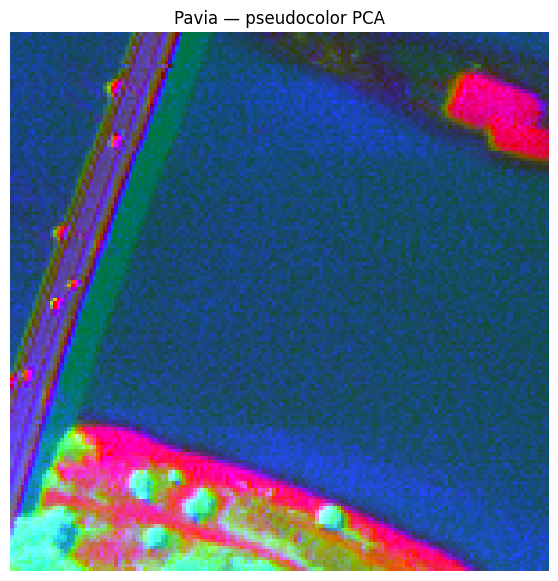

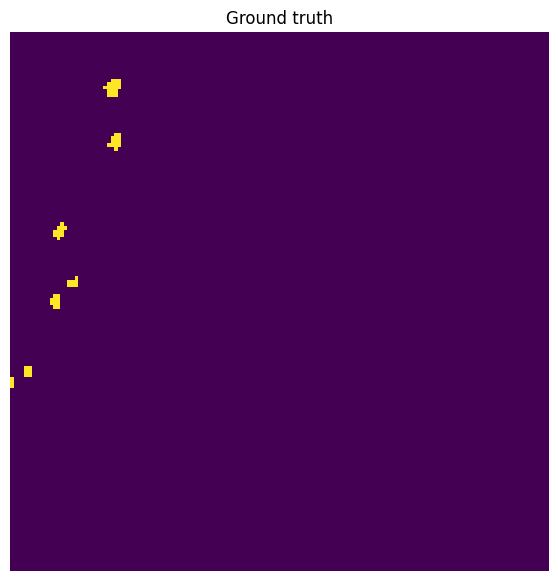

In [5]:
def percentile_stretch(image, low=2, high=98):
    output = np.zeros_like(image, dtype=np.float32)
    for channel in range(image.shape[-1]):
        band = image[..., channel]
        lo, hi = np.percentile(band, [low, high])
        if hi > lo:
            output[..., channel] = np.clip((band - lo) / (hi - lo), 0, 1)
    return output

pca = PCA(n_components=3, random_state=SEED)
pca_rgb = pca.fit_transform(pixels_z).reshape(H, W, 3)
pca_rgb = percentile_stretch(pca_rgb)

plt.figure(figsize=(7, 7))
plt.imshow(pca_rgb)
plt.title("Pavia — pseudocolor PCA")
plt.axis("off")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(gt_binary)
plt.title("Ground truth")
plt.axis("off")
plt.show()

## 5. Baseline GRX

In [6]:
def global_rx_scores(pixels_standardized, regularization=1e-3):
    mean_vector = pixels_standardized.mean(axis=0, keepdims=True)
    centered = pixels_standardized - mean_vector
    covariance = np.atleast_2d(np.cov(centered, rowvar=False))
    scale = np.trace(covariance) / covariance.shape[0]
    covariance_regularized = covariance + regularization * scale * np.eye(covariance.shape[0])
    inverse_covariance = np.linalg.pinv(covariance_regularized)
    return np.einsum("ij,jk,ik->i", centered, inverse_covariance, centered, optimize=True)

grx_start = time.perf_counter()
grx_scores_flat = global_rx_scores(pixels_z)
grx_time = time.perf_counter() - grx_start
grx_auc = roc_auc_score(y_true, grx_scores_flat)
grx_ap = average_precision_score(y_true, grx_scores_flat)

print("GRX ROC-AUC:", grx_auc)
print("GRX AP / PR-AUC:", grx_ap)
print("GRX timp:", grx_time, "s")

GRX ROC-AUC: 0.9677050117479231
GRX AP / PR-AUC: 0.3572593968841463
GRX timp: 0.14710616200000004 s


## 6. Dataset blind-block

In [7]:
class BlindBlockPatchDataset(Dataset):
    def __init__(self, hsi_hwc, wout, win, deterministic=False, seed=42):
        if hsi_hwc.ndim != 3:
            raise ValueError("HSI trebuie să aibă forma H x W x B.")
        if wout % 2 != 1 or win % 2 != 1:
            raise ValueError("Wout și Win trebuie să fie impare.")
        if win > wout:
            raise ValueError("Win nu poate fi mai mare decât Wout.")

        self.hsi = torch.from_numpy(hsi_hwc).float()
        self.h, self.w, self.b = hsi_hwc.shape
        self.wout = int(wout)
        self.win = int(win)
        self.pad = self.wout // 2
        self.center = self.wout // 2
        self.deterministic = bool(deterministic)
        self.seed = int(seed)

        chw = self.hsi.permute(2, 0, 1).unsqueeze(0)
        self.padded = F.pad(chw, (self.pad, self.pad, self.pad, self.pad), mode="reflect").squeeze(0)

        inner_half = self.win // 2
        inner_coords, outer_coords = [], []
        for row in range(self.wout):
            for col in range(self.wout):
                in_inner = abs(row - self.center) <= inner_half and abs(col - self.center) <= inner_half
                (inner_coords if in_inner else outer_coords).append((row, col))

        self.inner_coords = torch.tensor(inner_coords, dtype=torch.long)
        self.outer_coords = torch.tensor(outer_coords, dtype=torch.long)

    def __len__(self):
        return self.h * self.w

    def __getitem__(self, index):
        row = index // self.w
        col = index % self.w
        patch = self.padded[:, row:row + self.wout, col:col + self.wout].clone()
        target = self.hsi[row, col].clone()

        generator = None
        if self.deterministic:
            generator = torch.Generator()
            generator.manual_seed(self.seed + int(index))

        selected_ids = torch.randint(
            0,
            len(self.outer_coords),
            (len(self.inner_coords),),
            generator=generator,
        )
        source_coords = self.outer_coords[selected_ids]
        patch[:, self.inner_coords[:, 0], self.inner_coords[:, 1]] = patch[:, source_coords[:, 0], source_coords[:, 1]]
        return patch, target, int(index)

## 7. Arhitectura DirectNet

Numărul blocurilor ResNet este `Nr = (Wout - 7) / 4`.

In [8]:
class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        return x + residual

class DirectNet(nn.Module):
    def __init__(self, bands, wout, hidden_channels=64):
        super().__init__()
        if (wout - 7) % 4 != 0:
            raise ValueError("Wout trebuie să satisfacă Wout = 4*Nr + 7.")
        self.center = wout // 2
        self.n_res_blocks = (wout - 7) // 4
        self.conv_in = nn.Conv2d(bands, hidden_channels, 3, padding=1)
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_channels) for _ in range(self.n_res_blocks)])
        self.conv_penultimate = nn.Conv2d(hidden_channels, hidden_channels, 3, padding=1)
        self.bn_penultimate = nn.BatchNorm2d(hidden_channels)
        self.conv_out = nn.Conv2d(hidden_channels, bands, 3, padding=1)

    def forward(self, x):
        low_level = F.relu(self.conv_in(x), inplace=True)
        high_level = self.blocks(low_level)
        high_level = self.bn_penultimate(self.conv_penultimate(high_level))
        reconstructed_patch = self.conv_out(low_level + high_level)
        return reconstructed_patch[:, :, self.center, self.center]

## 8. Împărțirea train / validation

In [9]:
all_indices = np.arange(H * W)
split_rng = np.random.default_rng(SEED)
split_rng.shuffle(all_indices)
n_validation = min(VALIDATION_SAMPLES, max(1, int(0.1 * len(all_indices))))
validation_indices = all_indices[:n_validation]
training_indices = all_indices[n_validation:]

print("Train:", len(training_indices))
print("Validation:", len(validation_indices))

Train: 20700
Validation: 1800


## 9. Metrici și funcția de antrenare

In [10]:
def metrics_from_scores(y_true, scores):
    roc_auc = roc_auc_score(y_true, scores)
    average_precision = average_precision_score(y_true, scores)
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    best_index = int(np.argmax(tpr - fpr))
    threshold = float(thresholds[best_index])
    prediction = (scores >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction).ravel()
    return {
        "roc_auc": float(roc_auc),
        "average_precision": float(average_precision),
        "threshold": threshold,
        "precision": float(precision_score(y_true, prediction, zero_division=0)),
        "recall": float(recall_score(y_true, prediction, zero_division=0)),
        "f1": float(f1_score(y_true, prediction, zero_division=0)),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
        "prediction": prediction,
        "fpr": fpr,
        "tpr": tpr,
    }

In [11]:
def train_and_evaluate_config(wout, win, seed=SEED, verbose=True):
    if win > wout:
        raise ValueError("Win trebuie să fie <= Wout.")
    if (wout - 7) % 4 != 0:
        raise ValueError("Wout trebuie să fie de forma 4*Nr+7.")

    set_seed(seed)
    config_name = f"wout{wout}_win{win}"
    checkpoint_path = CHECKPOINT_DIR / f"{config_name}.pt"

    train_base = BlindBlockPatchDataset(hsi_z, wout, win, deterministic=False, seed=seed)
    val_base = BlindBlockPatchDataset(hsi_z, wout, win, deterministic=True, seed=seed + 10000)
    train_subset = Subset(train_base, training_indices.tolist())
    val_subset = Subset(val_base, validation_indices.tolist())

    sampler_generator = torch.Generator().manual_seed(seed)
    sampler = RandomSampler(
        train_subset,
        replacement=True,
        num_samples=TRAIN_SAMPLES_PER_EPOCH,
        generator=sampler_generator,
    )

    train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )
    val_loader = DataLoader(
        val_subset,
        batch_size=INFERENCE_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )

    model = DirectNet(B, wout, HIDDEN_CHANNELS).to(DEVICE)
    criterion = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6
    )

    best_state = None
    best_val = float("inf")
    wait = 0
    train_history, val_history = [], []
    start = time.perf_counter()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        train_sum, train_count = 0.0, 0
        for patches, targets, _ in train_loader:
            patches = patches.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            predictions = model(patches)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            train_sum += loss.item() * patches.shape[0]
            train_count += patches.shape[0]
        train_loss = train_sum / train_count

        model.eval()
        val_sum, val_count = 0.0, 0
        with torch.no_grad():
            for patches, targets, _ in val_loader:
                patches = patches.to(DEVICE, non_blocking=True)
                targets = targets.to(DEVICE, non_blocking=True)
                loss = criterion(model(patches), targets)
                val_sum += loss.item() * patches.shape[0]
                val_count += patches.shape[0]
        val_loss = val_sum / val_count
        scheduler.step(val_loss)
        train_history.append(train_loss)
        val_history.append(val_loss)

        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose:
            print(
                f"{config_name} | epoch {epoch:03d}/{MAX_EPOCHS} | "
                f"train={train_loss:.6f} | val={val_loss:.6f} | wait={wait}/{PATIENCE}"
            )
        if wait >= PATIENCE:
            print("Early stopping.")
            break

    training_time = time.perf_counter() - start
    if best_state is None:
        raise RuntimeError(f"Nu s-a salvat un model valid pentru {config_name}.")
    model.load_state_dict(best_state)
    torch.save(
        {
            "model_state_dict": best_state,
            "wout": wout,
            "win": win,
            "bands": B,
            "best_val_loss": best_val,
            "train_history": train_history,
            "val_history": val_history,
        },
        checkpoint_path,
    )

    eval_dataset = BlindBlockPatchDataset(hsi_z, wout, win, deterministic=True, seed=seed + 20000)
    eval_loader = DataLoader(
        eval_dataset,
        batch_size=INFERENCE_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
    )
    reconstructed = np.zeros((H * W, B), dtype=np.float32)
    model.eval()
    inference_start = time.perf_counter()
    with torch.no_grad():
        for patches, _, indices in eval_loader:
            predictions = model(patches.to(DEVICE, non_blocking=True)).cpu().numpy()
            reconstructed[indices.numpy()] = predictions
    inference_time = time.perf_counter() - inference_start

    scores = np.linalg.norm(hsi_z.reshape(-1, B) - reconstructed, axis=1)
    metrics = metrics_from_scores(y_true, scores)

    row = {
        "config": config_name,
        "wout": int(wout),
        "win": int(win),
        "n_res_blocks": int((wout - 7) // 4),
        "epochs_ran": len(train_history),
        "best_val_loss": float(best_val),
        "roc_auc": metrics["roc_auc"],
        "average_precision": metrics["average_precision"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "tp": metrics["tp"], "tn": metrics["tn"],
        "fp": metrics["fp"], "fn": metrics["fn"],
        "threshold": metrics["threshold"],
        "training_time_s": float(training_time),
        "inference_time_s": float(inference_time),
        "checkpoint": str(checkpoint_path),
    }
    artifacts = {
        "scores": scores,
        "score_map": scores.reshape(H, W),
        "prediction": metrics["prediction"],
        "prediction_map": metrics["prediction"].reshape(H, W),
        "fpr": metrics["fpr"],
        "tpr": metrics["tpr"],
        "train_history": np.array(train_history),
        "val_history": np.array(val_history),
    }

    del model, train_base, val_base, eval_dataset
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return row, artifacts

## 10. Sweep `Win`

Fixăm `Wout = 19` și testăm `Win = 1, 3, 5, 7, 9`. `Win = 1` este BaseNet/blind-spot.

In [12]:
win_results = []
win_artifacts = {}

for win in WIN_VALUES:
    print("\n" + "=" * 80)
    row, artifacts = train_and_evaluate_config(REFERENCE_WOUT, win)
    win_results.append(row)
    win_artifacts[row["config"]] = artifacts

win_df = pd.DataFrame(win_results).sort_values("win").reset_index(drop=True)
display(win_df)
win_df.to_csv(OUTPUT_DIR / "win_sweep_results.csv", index=False)


wout19_win1 | epoch 001/35 | train=0.297818 | val=0.162012 | wait=0/7
wout19_win1 | epoch 002/35 | train=0.147844 | val=0.136905 | wait=0/7
wout19_win1 | epoch 003/35 | train=0.136131 | val=0.123999 | wait=0/7
wout19_win1 | epoch 004/35 | train=0.125032 | val=0.117345 | wait=0/7
wout19_win1 | epoch 005/35 | train=0.116395 | val=0.107886 | wait=0/7
wout19_win1 | epoch 006/35 | train=0.107124 | val=0.112004 | wait=1/7
wout19_win1 | epoch 007/35 | train=0.102125 | val=0.095544 | wait=0/7
wout19_win1 | epoch 008/35 | train=0.099329 | val=0.103104 | wait=1/7
wout19_win1 | epoch 009/35 | train=0.094433 | val=0.090656 | wait=0/7
wout19_win1 | epoch 010/35 | train=0.093951 | val=0.107563 | wait=1/7
wout19_win1 | epoch 011/35 | train=0.089116 | val=0.087025 | wait=0/7
wout19_win1 | epoch 012/35 | train=0.085582 | val=0.086477 | wait=0/7
wout19_win1 | epoch 013/35 | train=0.081623 | val=0.087802 | wait=1/7
wout19_win1 | epoch 014/35 | train=0.081460 | val=0.083919 | wait=0/7
wout19_win1 | epoch

,config,wout,win,n_res_blocks,epochs_ran,best_val_loss,roc_auc,average_precision,precision,recall,f1,tp,tn,fp,fn,threshold,training_time_s,inference_time_s,checkpoint
0,wout19_win1,19,1,3,35,0.066141,0.991145,0.481893,0.075846,0.955882,0.140541,65,21640,792,3,2.191298,111.614906,7.606312,/content/directnet_experiments/checkpoints/wou...
1,wout19_win3,19,3,3,35,0.096337,0.984900,0.626215,0.042623,0.955882,0.081607,65,20972,1460,3,2.908882,105.572203,8.034283,/content/directnet_experiments/checkpoints/wou...
2,wout19_win5,19,5,3,35,0.114459,0.977988,0.666090,0.021417,0.955882,0.041895,65,19462,2970,3,2.442292,112.034709,10.171937,/content/directnet_experiments/checkpoints/wou...
3,wout19_win7,19,7,3,35,0.131752,0.978784,0.591589,0.045455,0.911765,0.086592,62,21130,1302,6,4.621486,122.108992,9.655022,/content/directnet_experiments/checkpoints/wou...
4,wout19_win9,19,9,3,35,0.151832,0.978759,0.513956,0.033109,0.941176,0.063968,64,20563,1869,4,4.308743,135.545763,10.980586,/content/directnet_experiments/checkpoints/wou...


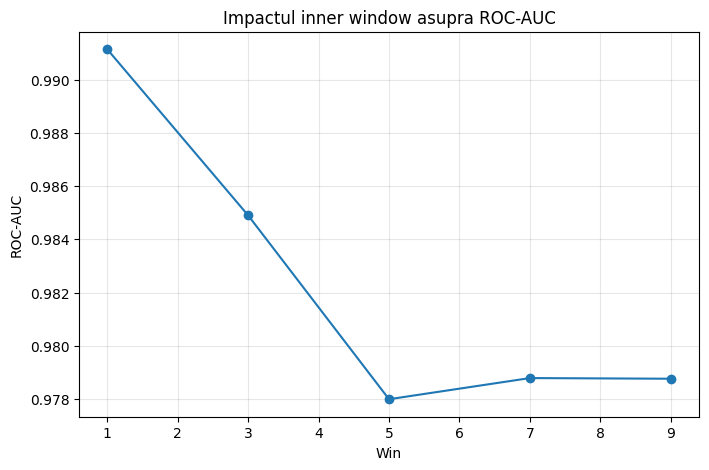

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(win_df["win"], win_df["roc_auc"], marker="o")
plt.xlabel("Win")
plt.ylabel("ROC-AUC")
plt.title("Impactul inner window asupra ROC-AUC")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "win_vs_roc_auc.png", dpi=200, bbox_inches="tight")
plt.show()

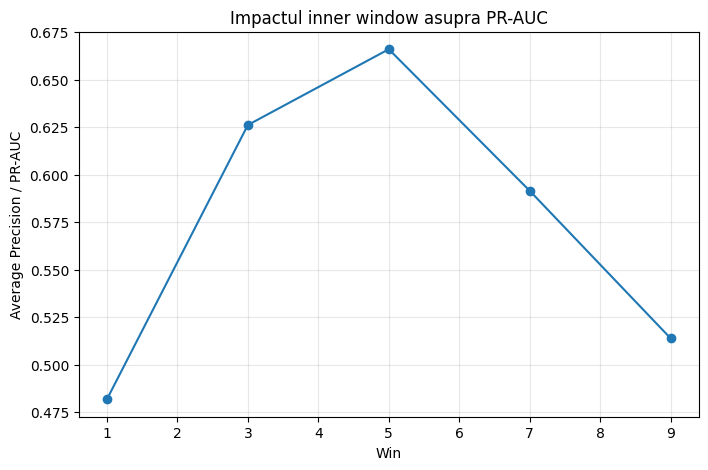

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(win_df["win"], win_df["average_precision"], marker="o")
plt.xlabel("Win")
plt.ylabel("Average Precision / PR-AUC")
plt.title("Impactul inner window asupra PR-AUC")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "win_vs_pr_auc.png", dpi=200, bbox_inches="tight")
plt.show()

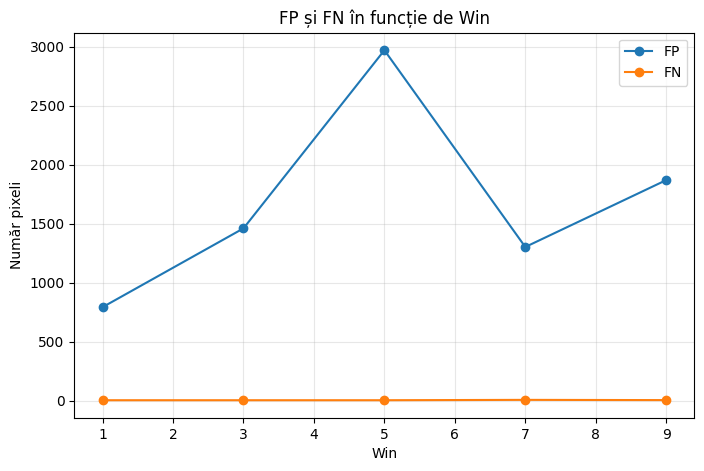

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(win_df["win"], win_df["fp"], marker="o", label="FP")
plt.plot(win_df["win"], win_df["fn"], marker="o", label="FN")
plt.xlabel("Win")
plt.ylabel("Număr pixeli")
plt.title("FP și FN în funcție de Win")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "win_vs_fp_fn.png", dpi=200, bbox_inches="tight")
plt.show()

## 11. Sweep `Wout`

Alegem cel mai bun `Win` după Average Precision și testăm `Wout = 15, 19, 23`.

In [16]:
best_win_row = win_df.loc[win_df["average_precision"].idxmax()]
BEST_WIN = int(best_win_row["win"])
print("Cel mai bun Win:", BEST_WIN)

wout_results = []
wout_artifacts = {}

for wout in WOUT_VALUES:
    config_name = f"wout{wout}_win{BEST_WIN}"
    if config_name in win_artifacts:
        existing = win_df[win_df["config"] == config_name].iloc[0].to_dict()
        wout_results.append(existing)
        wout_artifacts[config_name] = win_artifacts[config_name]
        print("Refolosesc:", config_name)
    else:
        print("\n" + "=" * 80)
        row, artifacts = train_and_evaluate_config(wout, BEST_WIN)
        wout_results.append(row)
        wout_artifacts[row["config"]] = artifacts

wout_df = pd.DataFrame(wout_results).sort_values("wout").reset_index(drop=True)
display(wout_df)
wout_df.to_csv(OUTPUT_DIR / "wout_sweep_results.csv", index=False)

Cel mai bun Win: 5

wout15_win5 | epoch 001/35 | train=0.383005 | val=0.257422 | wait=0/7
wout15_win5 | epoch 002/35 | train=0.214904 | val=0.212545 | wait=0/7
wout15_win5 | epoch 003/35 | train=0.199277 | val=0.194308 | wait=0/7
wout15_win5 | epoch 004/35 | train=0.190358 | val=0.183960 | wait=0/7
wout15_win5 | epoch 005/35 | train=0.179917 | val=0.183463 | wait=0/7
wout15_win5 | epoch 006/35 | train=0.163459 | val=0.176378 | wait=0/7
wout15_win5 | epoch 007/35 | train=0.166456 | val=0.161686 | wait=0/7
wout15_win5 | epoch 008/35 | train=0.167979 | val=0.164232 | wait=1/7
wout15_win5 | epoch 009/35 | train=0.154977 | val=0.154836 | wait=0/7
wout15_win5 | epoch 010/35 | train=0.160485 | val=0.150645 | wait=0/7
wout15_win5 | epoch 011/35 | train=0.149034 | val=0.146315 | wait=0/7
wout15_win5 | epoch 012/35 | train=0.142317 | val=0.142624 | wait=0/7
wout15_win5 | epoch 013/35 | train=0.140120 | val=0.146838 | wait=1/7
wout15_win5 | epoch 014/35 | train=0.138499 | val=0.149425 | wait=2/7


,config,wout,win,n_res_blocks,epochs_ran,best_val_loss,roc_auc,average_precision,precision,recall,f1,tp,tn,fp,fn,threshold,training_time_s,inference_time_s,checkpoint
0,wout15_win5,15,5,2,35,0.123625,0.976561,0.652057,0.041468,0.897059,0.079272,61,21022,1410,7,4.057705,69.803463,6.120529,/content/directnet_experiments/checkpoints/wou...
1,wout19_win5,19,5,3,35,0.114459,0.977988,0.666090,0.021417,0.955882,0.041895,65,19462,2970,3,2.442292,112.034709,10.171937,/content/directnet_experiments/checkpoints/wou...
2,wout23_win5,23,5,4,35,0.111154,0.978368,0.679124,0.028559,0.955882,0.055461,65,20221,2211,3,2.837069,162.006929,12.566739,/content/directnet_experiments/checkpoints/wou...


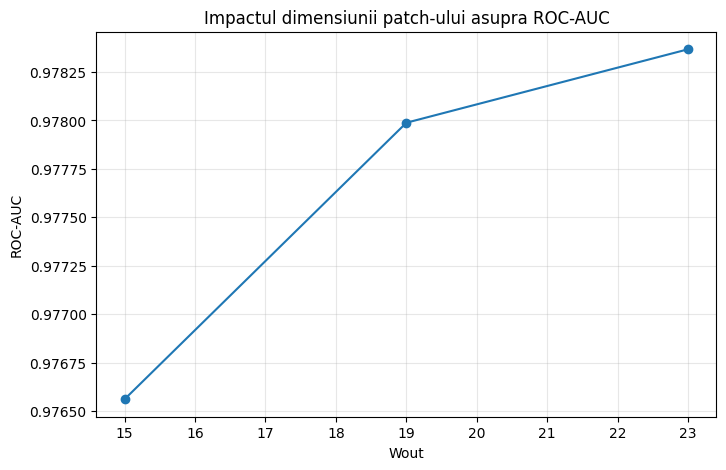

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(wout_df["wout"], wout_df["roc_auc"], marker="o")
plt.xlabel("Wout")
plt.ylabel("ROC-AUC")
plt.title("Impactul dimensiunii patch-ului asupra ROC-AUC")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "wout_vs_roc_auc.png", dpi=200, bbox_inches="tight")
plt.show()

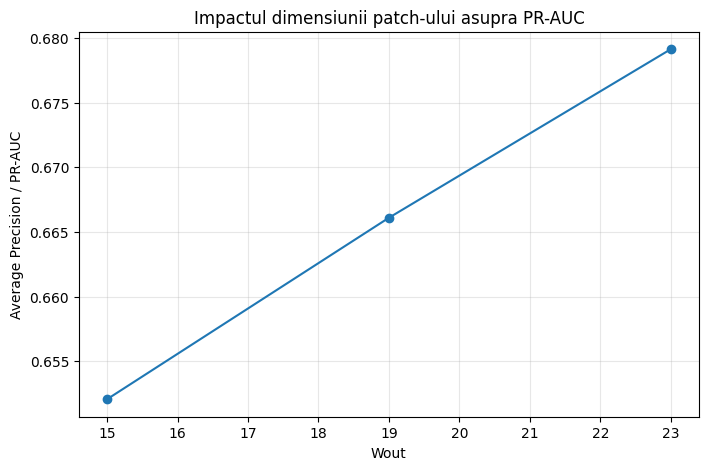

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(wout_df["wout"], wout_df["average_precision"], marker="o")
plt.xlabel("Wout")
plt.ylabel("Average Precision / PR-AUC")
plt.title("Impactul dimensiunii patch-ului asupra PR-AUC")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "wout_vs_pr_auc.png", dpi=200, bbox_inches="tight")
plt.show()

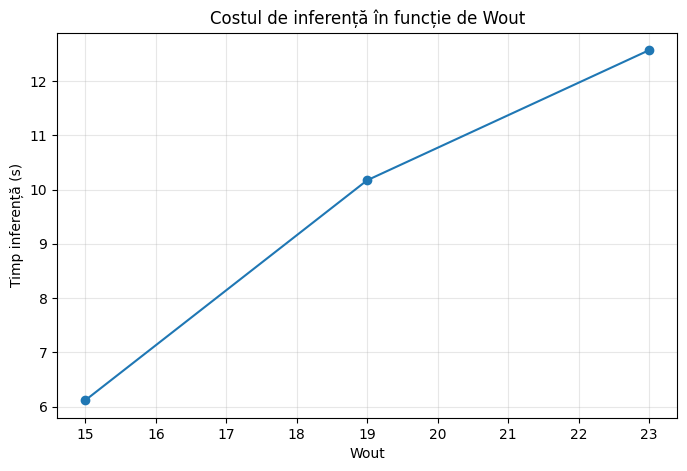

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(wout_df["wout"], wout_df["inference_time_s"], marker="o")
plt.xlabel("Wout")
plt.ylabel("Timp inferență (s)")
plt.title("Costul de inferență în funcție de Wout")
plt.grid(alpha=0.3)
plt.savefig(FIGURE_DIR / "wout_vs_inference_time.png", dpi=200, bbox_inches="tight")
plt.show()

## 12. Alegerea configurației finale

In [20]:
all_results_df = pd.concat([win_df, wout_df], ignore_index=True).drop_duplicates("config").reset_index(drop=True)
best_row = all_results_df.loc[all_results_df["average_precision"].idxmax()]
BEST_CONFIG = str(best_row["config"])
all_results_df.to_csv(OUTPUT_DIR / "all_experiment_results.csv", index=False)

all_artifacts = {}
all_artifacts.update(win_artifacts)
all_artifacts.update(wout_artifacts)
best_artifacts = all_artifacts[BEST_CONFIG]
best_scores = best_artifacts["scores"]
best_score_map = best_artifacts["score_map"]
best_prediction = best_artifacts["prediction"]
best_prediction_map = best_artifacts["prediction_map"]

print("Configurația finală:", BEST_CONFIG)
print(best_row)

Configurația finală: wout23_win5
config                                                     wout23_win5
wout                                                                23
win                                                                  5
n_res_blocks                                                         4
epochs_ran                                                          35
best_val_loss                                                 0.111154
roc_auc                                                       0.978368
average_precision                                             0.679124
precision                                                     0.028559
recall                                                        0.955882
f1                                                            0.055461
tp                                                                  65
tn                                                               20221
fp                                          

## 13. ROC și Precision–Recall: GRX versus configurația finală

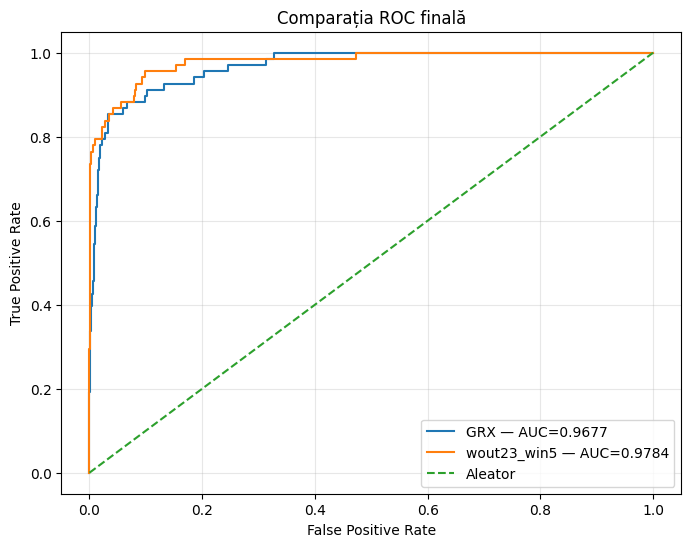

In [21]:
best_fpr, best_tpr, _ = roc_curve(y_true, best_scores)
grx_fpr, grx_tpr, _ = roc_curve(y_true, grx_scores_flat)

plt.figure(figsize=(8, 6))
plt.plot(grx_fpr, grx_tpr, label=f"GRX — AUC={grx_auc:.4f}")
plt.plot(best_fpr, best_tpr, label=f"{BEST_CONFIG} — AUC={best_row['roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], "--", label="Aleator")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparația ROC finală")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "final_roc_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

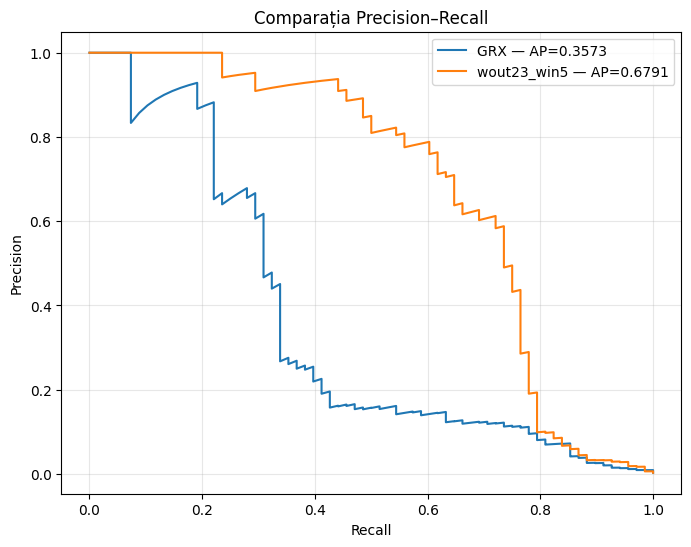

In [22]:
grx_precision_curve, grx_recall_curve, _ = precision_recall_curve(y_true, grx_scores_flat)
best_precision_curve, best_recall_curve, _ = precision_recall_curve(y_true, best_scores)

plt.figure(figsize=(8, 6))
plt.plot(grx_recall_curve, grx_precision_curve, label=f"GRX — AP={grx_ap:.4f}")
plt.plot(
    best_recall_curve,
    best_precision_curve,
    label=f"{BEST_CONFIG} — AP={best_row['average_precision']:.4f}",
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Comparația Precision–Recall")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "final_precision_recall_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

## 14. Harta finală și separabilitatea

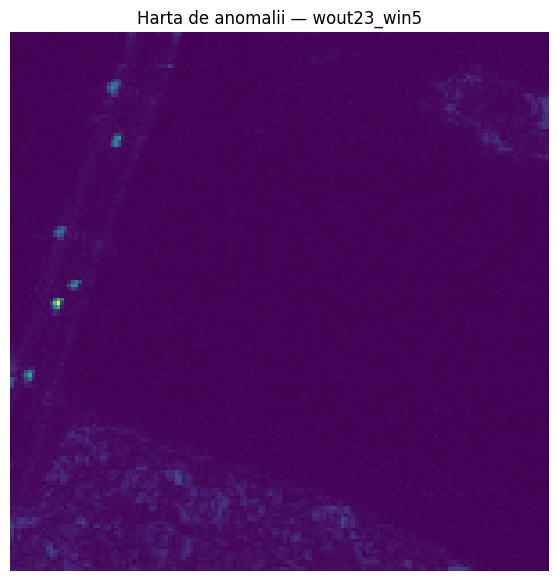

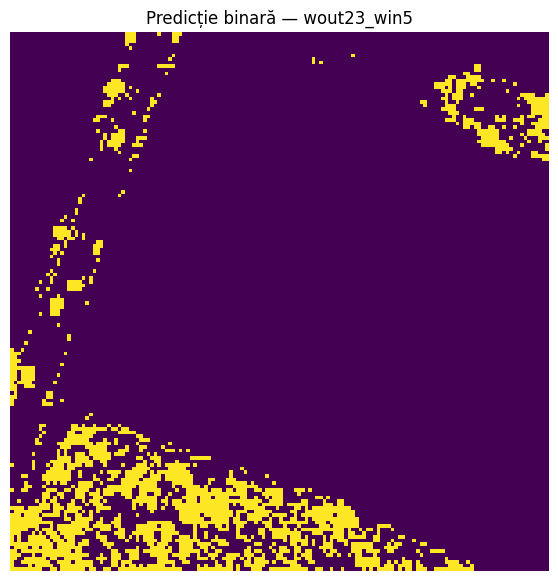

In [23]:
score_display = (best_score_map - best_score_map.min()) / (best_score_map.max() - best_score_map.min() + 1e-12)

plt.figure(figsize=(7, 7))
plt.imshow(score_display)
plt.title(f"Harta de anomalii — {BEST_CONFIG}")
plt.axis("off")
plt.savefig(FIGURE_DIR / "best_anomaly_map.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(7, 7))
plt.imshow(best_prediction_map)
plt.title(f"Predicție binară — {BEST_CONFIG}")
plt.axis("off")
plt.savefig(FIGURE_DIR / "best_binary_prediction.png", dpi=200, bbox_inches="tight")
plt.show()

/tmp/ipykernel_1805/2509748411.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([background_scores, anomaly_scores], labels=["Fundal", "Anomalie"], showfliers=False)


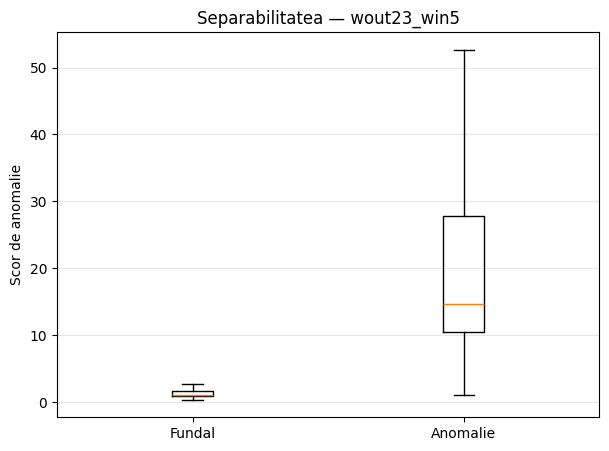

Mediană fundal: 1.0795174
Mediană anomalie: 14.66042


In [24]:
background_scores = best_scores[y_true == 0]
anomaly_scores = best_scores[y_true == 1]

plt.figure(figsize=(7, 5))
plt.boxplot([background_scores, anomaly_scores], labels=["Fundal", "Anomalie"], showfliers=False)
plt.ylabel("Scor de anomalie")
plt.title(f"Separabilitatea — {BEST_CONFIG}")
plt.grid(axis="y", alpha=0.3)
plt.savefig(FIGURE_DIR / "best_separability_boxplot.png", dpi=200, bbox_inches="tight")
plt.show()

print("Mediană fundal:", np.median(background_scores))
print("Mediană anomalie:", np.median(anomaly_scores))

## 15. Analiza pragului

Comparăm mai multe percentile ale scorului. Pragurile mari reduc FP, dar pot crește FN.

In [25]:
percentiles = [95, 97, 98, 99, 99.25, 99.5, 99.7, 99.8, 99.9]
threshold_rows = []

for percentile in percentiles:
    threshold = float(np.percentile(best_scores, percentile))
    prediction = (best_scores >= threshold).astype(np.uint8)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction).ravel()
    threshold_rows.append({
        "percentile": percentile,
        "threshold": threshold,
        "precision": precision_score(y_true, prediction, zero_division=0),
        "recall": recall_score(y_true, prediction, zero_division=0),
        "f1": f1_score(y_true, prediction, zero_division=0),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)
threshold_df.to_csv(OUTPUT_DIR / "threshold_analysis.csv", index=False)

,percentile,threshold,precision,recall,f1,tp,tn,fp,fn
0,95.00,4.209722,0.052444,0.867647,0.098910,59,21366,1066,9
1,97.00,5.246930,0.084444,0.838235,0.153432,57,21814,618,11
2,98.00,6.189261,0.120000,0.794118,0.208494,54,22036,396,14
3,99.00,8.142453,0.235556,0.779412,0.361775,53,22260,172,15
4,99.25,8.891209,0.307692,0.764706,0.438819,52,22315,117,16
5,99.50,10.184400,0.451327,0.750000,0.563536,51,22370,62,17
6,99.70,12.447680,0.647059,0.647059,0.647059,44,22408,24,24
7,99.80,14.294702,0.822222,0.544118,0.654867,37,22424,8,31
8,99.90,24.198927,0.913043,0.308824,0.461538,21,22430,2,47


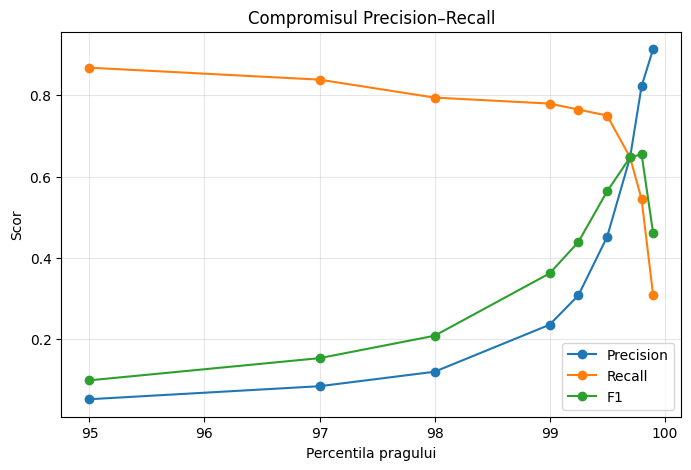

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["percentile"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["percentile"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["percentile"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Percentila pragului")
plt.ylabel("Scor")
plt.title("Compromisul Precision–Recall")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "threshold_precision_recall_f1.png", dpi=200, bbox_inches="tight")
plt.show()

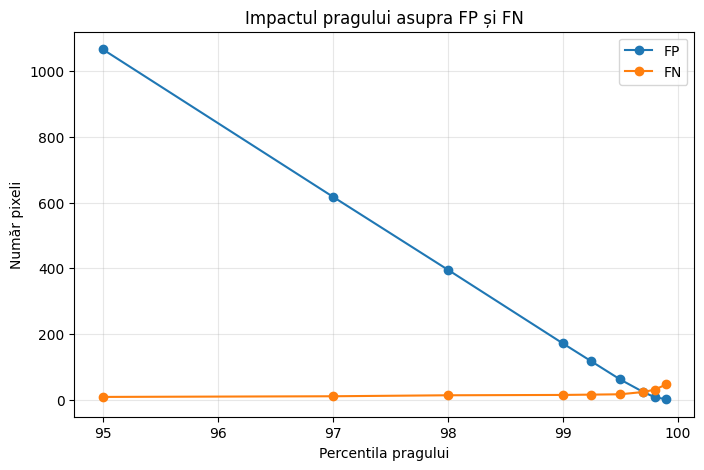

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["percentile"], threshold_df["fp"], marker="o", label="FP")
plt.plot(threshold_df["percentile"], threshold_df["fn"], marker="o", label="FN")
plt.xlabel("Percentila pragului")
plt.ylabel("Număr pixeli")
plt.title("Impactul pragului asupra FP și FN")
plt.grid(alpha=0.3)
plt.legend()
plt.savefig(FIGURE_DIR / "threshold_fp_fn.png", dpi=200, bbox_inches="tight")
plt.show()

## 16. Cazuri concrete de False Positives și False Negatives

În fiecare panou: `Pseudocolor | Scor | Ground truth | Predicție`. Pătratul alb marchează pixelul analizat.

In [28]:
def normalize_grayscale(array):
    array = np.asarray(array, dtype=np.float32)
    lo, hi = float(array.min()), float(array.max())
    return np.zeros_like(array) if hi <= lo else (array - lo) / (hi - lo)


def crop_bounds(row, col, radius):
    return (
        max(0, row - radius),
        min(H, row + radius + 1),
        max(0, col - radius),
        min(W, col + radius + 1),
    )


def build_case_panel(flat_index, case_name, crop_radius=10):
    row, col = int(flat_index // W), int(flat_index % W)
    r0, r1, c0, c1 = crop_bounds(row, col, crop_radius)
    pca_crop = pca_rgb[r0:r1, c0:c1].copy()
    lr, lc = row - r0, col - c0
    pca_crop[max(0, lr - 1):min(pca_crop.shape[0], lr + 2), max(0, lc - 1):min(pca_crop.shape[1], lc + 2)] = 1.0

    score_crop = normalize_grayscale(best_score_map[r0:r1, c0:c1])
    score_rgb = np.repeat(score_crop[..., None], 3, axis=2)
    gt_rgb = np.repeat(gt_binary[r0:r1, c0:c1, None].astype(np.float32), 3, axis=2)
    pred_rgb = np.repeat(best_prediction_map[r0:r1, c0:c1, None].astype(np.float32), 3, axis=2)
    separator = np.ones((pca_crop.shape[0], 2, 3), dtype=np.float32)
    panel = np.concatenate([pca_crop, separator, score_rgb, separator, gt_rgb, separator, pred_rgb], axis=1)

    title = (
        f"{case_name} | coord=({row}, {col}) | score={best_scores[flat_index]:.4f} | "
        f"GT={int(y_true[flat_index])} | pred={int(best_prediction[flat_index])}\n"
        "Pseudocolor | Scor | Ground truth | Predicție"
    )
    return panel, title

fp_indices = np.where((y_true == 0) & (best_prediction == 1))[0]
fn_indices = np.where((y_true == 1) & (best_prediction == 0))[0]
selected_fp = fp_indices[np.argsort(best_scores[fp_indices])[::-1]][:3]
selected_fn = list(fn_indices[np.argsort(best_scores[fn_indices])[::-1]][:2])
if len(fn_indices) >= 3:
    hardest_fn = int(fn_indices[np.argmin(best_scores[fn_indices])])
    if hardest_fn not in selected_fn:
        selected_fn.append(hardest_fn)

print("FP selectate:", selected_fp.tolist())
print("FN selectate:", selected_fn)

FP selectate: [11114, 14405, 18496]
FN selectate: [np.int64(7964), np.int64(10962), 10218]


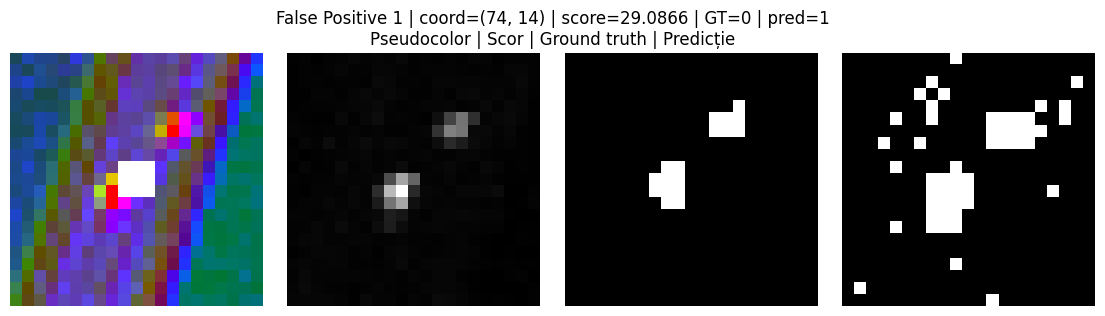

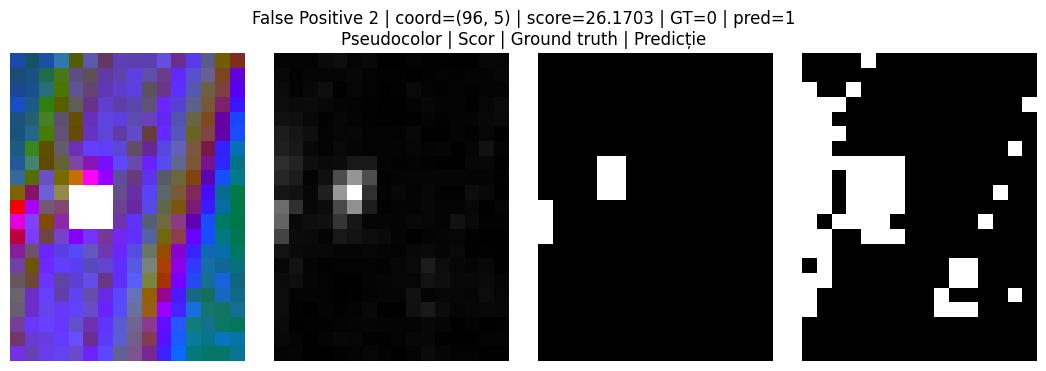

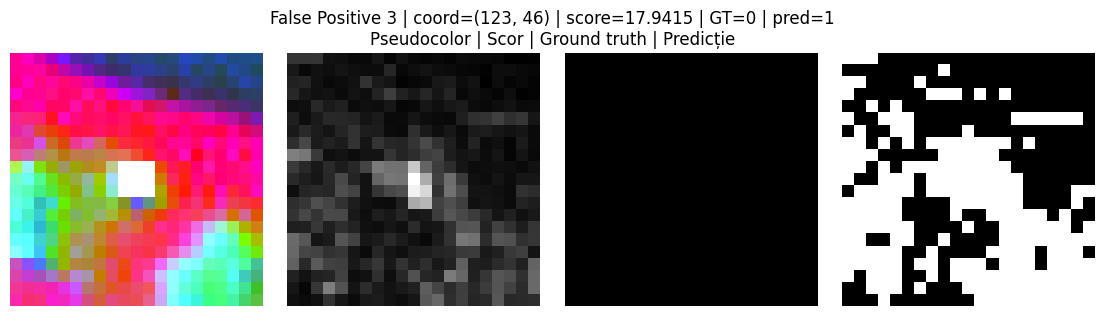

In [29]:
for number, flat_index in enumerate(selected_fp, start=1):
    panel, title = build_case_panel(int(flat_index), f"False Positive {number}")
    plt.figure(figsize=(14, 4))
    plt.imshow(panel)
    plt.title(title)
    plt.axis("off")
    plt.savefig(FIGURE_DIR / f"false_positive_{number}.png", dpi=200, bbox_inches="tight")
    plt.show()

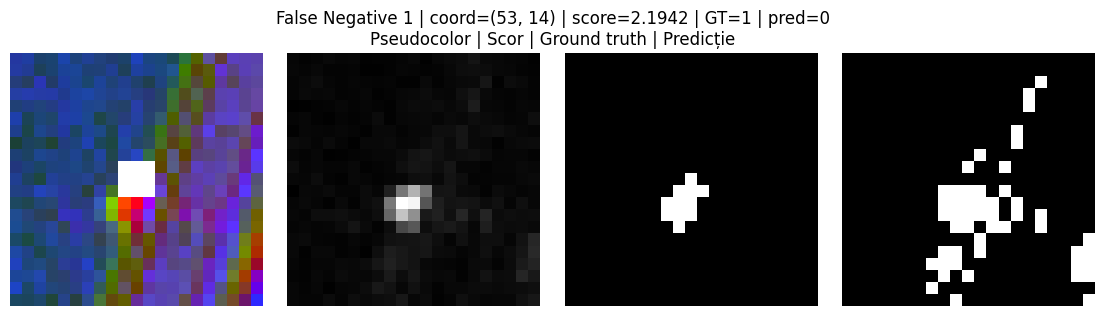

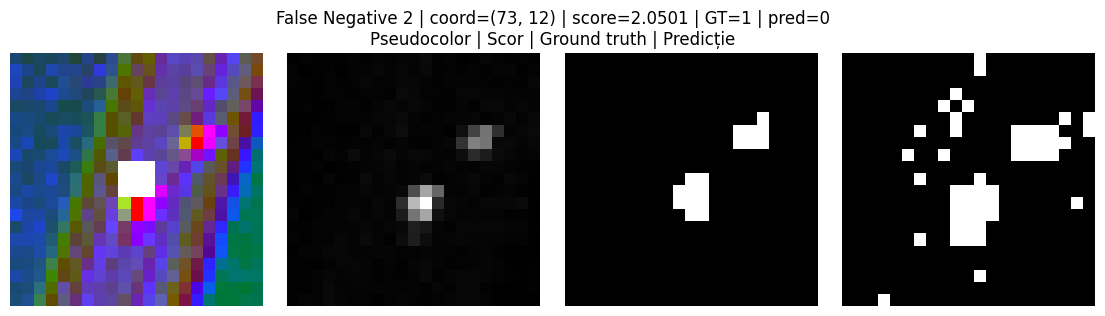

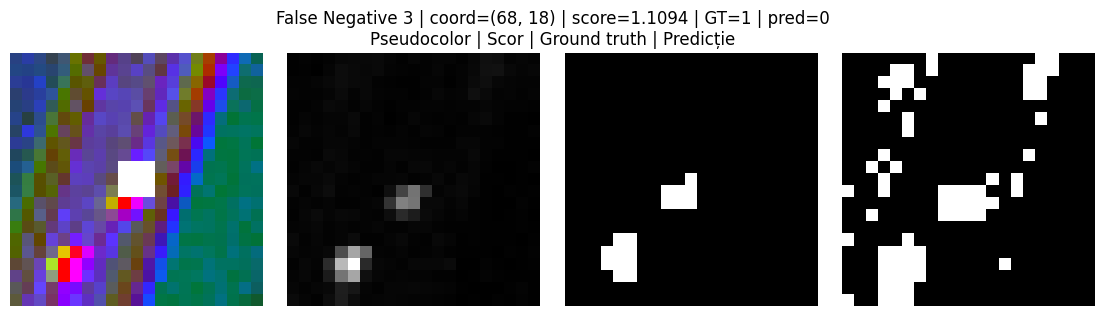

In [30]:
if not selected_fn:
    print("Nu există False Negatives la pragul Youden.")
else:
    for number, flat_index in enumerate(selected_fn, start=1):
        panel, title = build_case_panel(int(flat_index), f"False Negative {number}")
        plt.figure(figsize=(14, 4))
        plt.imshow(panel)
        plt.title(title)
        plt.axis("off")
        plt.savefig(FIGURE_DIR / f"false_negative_{number}.png", dpi=200, bbox_inches="tight")
        plt.show()

## 17. Tabelul final și arhiva ZIP

In [31]:
grx_metrics = metrics_from_scores(y_true, grx_scores_flat)
grx_row = {
    "config": "GRX",
    "wout": np.nan,
    "win": np.nan,
    "n_res_blocks": 0,
    "epochs_ran": 0,
    "best_val_loss": np.nan,
    "roc_auc": grx_metrics["roc_auc"],
    "average_precision": grx_metrics["average_precision"],
    "precision": grx_metrics["precision"],
    "recall": grx_metrics["recall"],
    "f1": grx_metrics["f1"],
    "tp": grx_metrics["tp"], "tn": grx_metrics["tn"],
    "fp": grx_metrics["fp"], "fn": grx_metrics["fn"],
    "threshold": grx_metrics["threshold"],
    "training_time_s": 0.0,
    "inference_time_s": grx_time,
    "checkpoint": "-",
}

presentation_table = pd.concat([pd.DataFrame([grx_row]), all_results_df], ignore_index=True)
presentation_table = presentation_table[
    [
        "config", "wout", "win", "roc_auc", "average_precision",
        "precision", "recall", "f1", "fp", "fn",
        "training_time_s", "inference_time_s",
    ]
].sort_values("average_precision", ascending=False).reset_index(drop=True)

display(presentation_table)
presentation_table.to_csv(OUTPUT_DIR / "presentation_results_table.csv", index=False)

,config,wout,win,roc_auc,average_precision,precision,recall,f1,fp,fn,training_time_s,inference_time_s
0,wout23_win5,23.0,5.0,0.978368,0.679124,0.028559,0.955882,0.055461,2211,3,162.006929,12.566739
1,wout19_win5,19.0,5.0,0.977988,0.666090,0.021417,0.955882,0.041895,2970,3,112.034709,10.171937
2,wout15_win5,15.0,5.0,0.976561,0.652057,0.041468,0.897059,0.079272,1410,7,69.803463,6.120529
3,wout19_win3,19.0,3.0,0.984900,0.626215,0.042623,0.955882,0.081607,1460,3,105.572203,8.034283
4,wout19_win7,19.0,7.0,0.978784,0.591589,0.045455,0.911765,0.086592,1302,6,122.108992,9.655022
5,wout19_win9,19.0,9.0,0.978759,0.513956,0.033109,0.941176,0.063968,1869,4,135.545763,10.980586
6,wout19_win1,19.0,1.0,0.991145,0.481893,0.075846,0.955882,0.140541,792,3,111.614906,7.606312
7,GRX,NaN,NaN,0.967705,0.357259,0.072500,0.852941,0.133641,742,10,0.000000,0.147106


In [32]:
import shutil
archive_path = shutil.make_archive("/content/directnet_experiments", "zip", OUTPUT_DIR)
print("Arhivă creată:", archive_path)
print("Descarcă directnet_experiments.zip din panoul Files al Colab-ului.")

Arhivă creată: /content/directnet_experiments.zip
Descarcă directnet_experiments.zip din panoul Files al Colab-ului.


# Ce pui în prezentare după rulare

1. tabelul GRX vs DirectNet;
2. `Win vs ROC-AUC` și `Win vs PR-AUC`;
3. `Wout vs ROC-AUC` și timpul de inferență;
4. curba Precision–Recall;
5. graficul pragului și compromisului FP/FN;
6. câte un caz clar de FP și FN;
7. observația că un singur seed și o singură scenă limitează generalizarea concluziilor.